Image preprocessing:
1. Normalize contrast/brightness effects
2. Z-score
3. Gamma Correction
4. Color space transformation (Ex: RGB to LAB)
5. Cropped/resize/fixed sized image

In [ ]:
import cv2 
import numpy as np
from matplotlib import pyplot as plt
input = cv2.imread('./images/input.jpg')
cv2.imshow('Hello Computer Vision ', input)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)
print(('Height of Image:')  , int(input.shape[0]), 'pixels')
print(('Width of Image: ')  , int(input.shape[1]), 'pixels')
print(('Channel of Image: '), int(input.shape[2]),'Channels')
B, G, R = cv2.split(input)
#merged = cv2.merge([B,G,R])
#merged = cv2.merge([B+100, G, R])
#cv2.imshow("Merged with Blue Amplified", merged)  
#cv2.imwrite('./images/input.jpg', input)
#hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
#cv2.imshow('HSV image', hsv_image)
#cv2.imshow('Hue channel', hsv_image[:, :, 0])
#cv2.imshow('Saturation channel', hsv_image[:, :, 1])
#cv2.imshow('Value channel', hsv_image[:, :, 2])
#cv2.waitKey(0)
#cv2.destroyAllWindows()
#cv2.waitKey(1)
plt.hist(input.ravel(), 256, [0, 256]);
plt.show()

color = ('b', 'g', 'r')

for i, col in enumerate(color):
    histogram2 = cv2.calcHist([input], [i], None, [256], [0, 256])
    plt.plot(histogram2, color = col)
    plt.xlim([0,256])
    
plt.show()




Sharpening

Sharpening can be achieved by changing the kernel. 
It has the effect of enhancing or emphasizing the edges of an image.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('images/input.jpg')
#image = cv2.imread('images/Bitmap.bmp')
cv2.imshow('Original', image)


kernel_sharpening = np.array([[-1,-1,-1], 
                              [-1,9,-1], 
                              [-1,-1,-1]])


sharpened = cv2.filter2D(image, -1, kernel_sharpening)
fig = plt.figure(figsize=(15,15))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title('Original image')
ax1.imshow(image, cmap='gray')
ax2.set_title('sharpened image')
ax2.imshow(sharpened, cmap='gray')
'''
cv2.imshow('Image Sharpening', sharpened)

cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)
cv2.imwrite('images/newBitmap.bmp', sharpened)
'''

Thresholding, Binarization & Adaptive Thresholding

Thresholding
Convert a grey scale image to it's binary 

In [ ]:
import cv2
import numpy as np

# Load our image as greyscale 
image = cv2.imread('images/gradient.jpg',0)
#cv2.imshow('Original', image)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)

ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

#cv2.imshow('1 Threshold Binary', thresh1)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)

ret,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

#cv2.imshow('2 Threshold Binary Inverse', thresh2)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)

ret,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

#cv2.imshow('3 THRESH TRUNC', thresh3)

# Values below 127 go to 0, above 127 are unchanged  

ret,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

#cv2.imshow('4 THRESH TOZERO', thresh4)


# Resever of above, below 127 is unchanged, above 127 goes to 0

ret,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
#cv2.imshow('5 THRESH TOZERO INV', thresh5)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)

ax1.set_title('Original image')
ax1.imshow(image, cmap='gray')
ax2.set_title('1 Threshold Binary')
ax2.imshow(thresh1, cmap='gray')
ax3.set_title('2 Threshold Binary Inverse')
ax3.imshow(thresh2, cmap='gray')
ax4.set_title('3 THRESH TRUNC')
ax4.imshow(thresh3, cmap='gray')
ax5.set_title('4 THRESH TOZERO')
ax5.imshow(thresh4, cmap='gray')
ax6.set_title('5 THRESH TOZERO INV')
ax6.imshow(thresh5, cmap='gray')

'''
cv2.waitKey(0) 
    
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)
'''

Adaptive Thresholding 

In [ ]:
import cv2
import numpy as np

# Load 加載 圖像 
image = cv2.imread('images/Origin_of_Species.jpg', 0)

#cv2.imshow('Original', image)
#cv2.waitKey(0) 


#  Values below 127 goes to 0 (black, everything above goes to 255 (white)


ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
#cv2.imshow('Threshold Binary', thresh1)
#cv2.waitKey(0) 


# It's good practice to blur images as it removes noise


gblur = cv2.GaussianBlur(image, (3, 3), 0)


# Using adaptiveThreshold

th2 = cv2.adaptiveThreshold(gblur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                               cv2.THRESH_BINARY, 3, 5) 
#cv2.imshow("Adaptive Mean Thresholding", thresh) 
#cv2.waitKey(0) 

_, th3 = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#cv2.imshow("Otsu's Thresholding", thresh) 
#cv2.waitKey(0) 

# Otsu's thresholding after Gaussian filtering


blur = cv2.GaussianBlur(image, (3,3), 0)
_, th4 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#cv2.imshow("Guassian Otsu's Thresholding", thresh) 

fig = plt.figure(figsize=(15,15))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax1.set_title('Original image')
ax1.imshow(image, cmap='gray')
ax2.set_title('Threshold Binary')
ax2.imshow(thresh1, cmap='gray')
ax3.set_title('Adaptive Mean Thresholding')
ax3.imshow(th2, cmap='gray')
ax4.set_title('Otsu\'s Thresholding')
ax4.imshow(th3, cmap='gray')
ax5.set_title('4 THRESH TOZERO')
ax5.imshow(th4, cmap='gray')



'''
cv2.waitKey(0) 
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)
'''

Dilation, Erosion, 
MORPH_OPEN/MORPH_CLOSE 

In [4]:
import cv2
import numpy as np

image = cv2.imread('images/opencv_inv.png', 0)

cv2.imshow('Original', image)
cv2.waitKey(0)


# define our kernel size


kernel = np.ones((5,5), np.uint8)



# Erode


erosion = cv2.erode(image, kernel, iterations = 1)
cv2.imshow('Erosion', erosion)
cv2.waitKey(0)

# 
dilation = cv2.dilate(image, kernel, iterations = 1)
cv2.imshow('Dilation', dilation)
cv2.waitKey(0)



# MORPH_OPEN  - Good for removing noise


opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
cv2.imshow('Opening', opening)
cv2.waitKey(0)


# MORPH_CLOSE  - Good for removing noise


closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
cv2.imshow('Closing', closing)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Edge Detection & Image Gradients

In [5]:
import cv2
import numpy as np

image = cv2.imread('images/input.jpg',0)

height, width = image.shape

# 提取 Sobel 邊緣檢測 
# Extract Sobel Edges

sobel_x = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)

cv2.imshow('Original', image)
cv2.waitKey(0)
cv2.imshow('Sobel X', sobel_x)
cv2.waitKey(0)
cv2.imshow('Sobel Y', sobel_y)
cv2.waitKey(0)


sobel_OR = cv2.bitwise_or(sobel_x, sobel_y)
cv2.imshow('sobel_OR', sobel_OR)
cv2.waitKey(0)

laplacian = cv2.Laplacian(image, cv2.CV_64F)
cv2.imshow('Laplacian', laplacian)
cv2.waitKey(0)




# Canny Edge Detection uses gradient values as thresholds

# threshold1 & threshold2 
# gradient greater than threshold2 => edge
# 
# lower than threshold1 => not edge
# between threshold1 & threshold2 => check the continuity of intensities

canny = cv2.Canny(image, 50, 120)
cv2.imshow('Canny', canny)
cv2.waitKey(0)

cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Perpsective Transform

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/scan.jpg')

cv2.imshow('Original', image)
cv2.waitKey(0)

# Cordinates of the 4 corners of the original image

points_A = np.float32([[320,15], [700,215], [85,610], [530,780]])



points_B = np.float32([[0,0], [420,0], [0,594], [420,594]])
 

# Perspective Transformation matrix, M 

M = cv2.getPerspectiveTransform(points_A, points_B)
 
warped = cv2.warpPerspective(image, M, (420,594))
 
cv2.imshow('warpPerspective', warped)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

In affine transforms only need 3 coordiantes to obtain the correct transform

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('images/ex2.jpg')
rows,cols,ch = image.shape

cv2.imshow('Original', image)
cv2.waitKey(0)

# Cordinates of the 4 corners of the original image

points_A = np.float32([[320,15], [700,215], [85,610]])


points_B = np.float32([[0,0], [420,0], [0,594]])
 
    
    
# M -  Perspective Transformation matrix, M 


M = cv2.getAffineTransform(points_A, points_B)

warped = cv2.warpAffine(image, M, (cols, rows))
 
cv2.imshow('warpPerspective', warped)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

1. warpAffine() 平移影像 (M = np.float32([[1, 0, 100], [0, 1, 100]]))
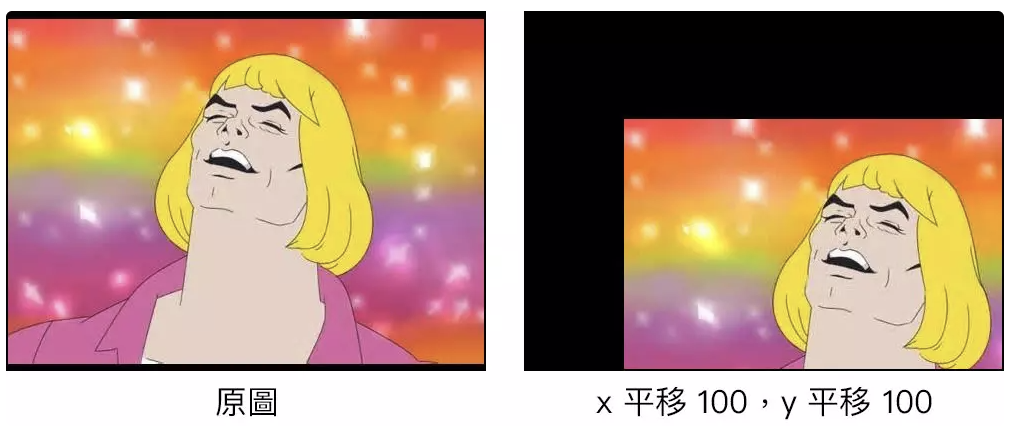
2. getRotationMatrix2D() 旋轉影像 + warpAffine()
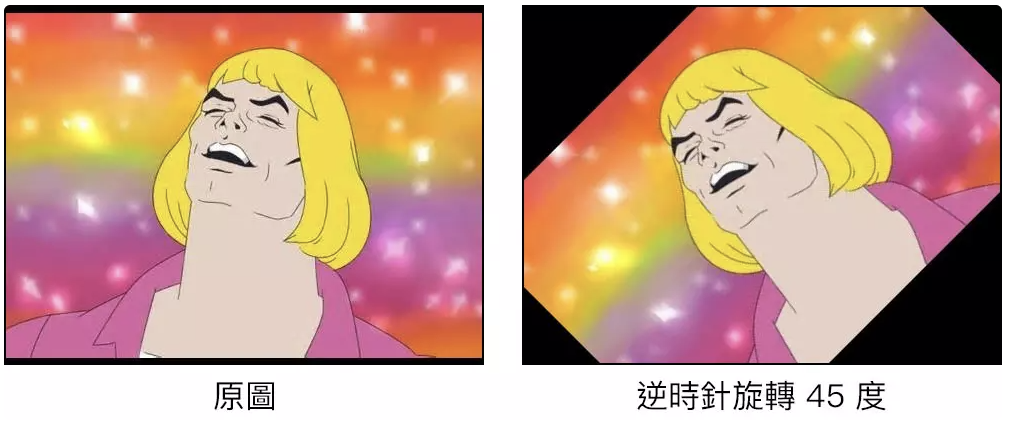
3. getAffineTransform() 影像仿射變換 + warpAffine()
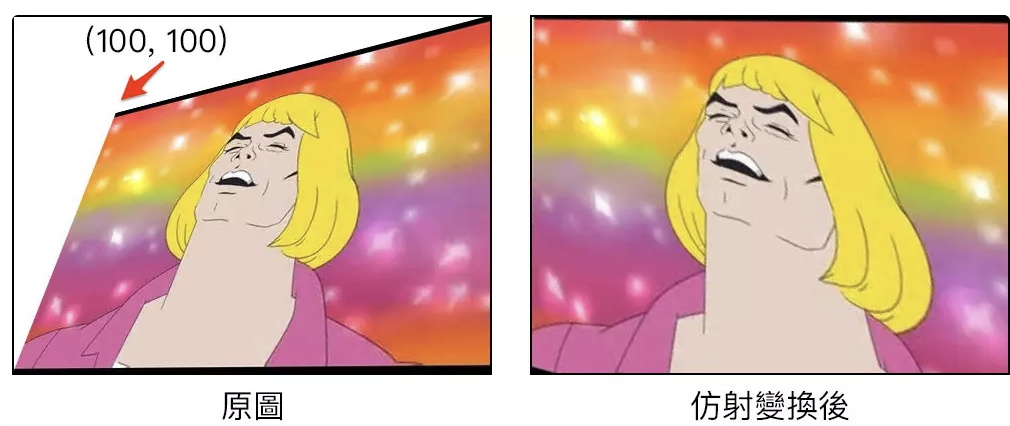
4. warpPerspective() + getPerspectiveTransform() 影像透視
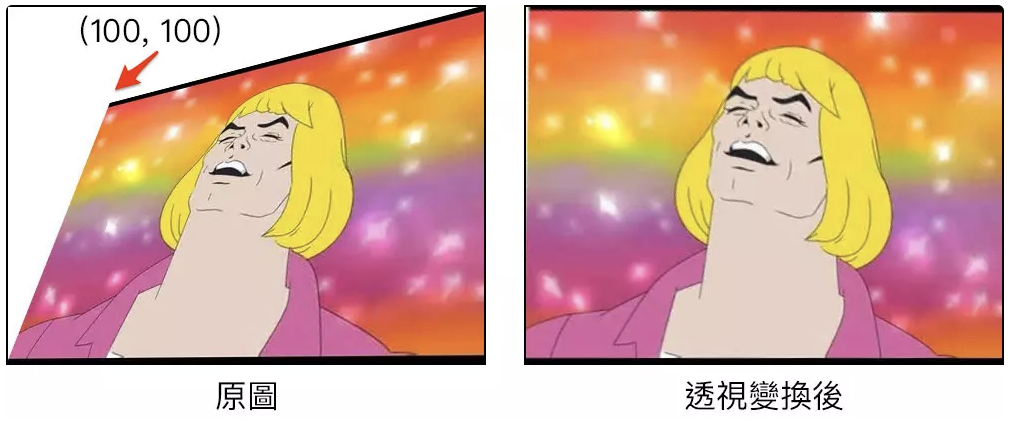

In [18]:
import cv2
import numpy as np

# 生成素描圖 功能 Sketch Generating Function

def sketch(image):
    # Convert 圖像 轉換為 灰度 
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 高斯模糊 Guassian Blur 清理圖像  Image
    img_gray_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
    
    # 提取邊緣  Edges
    canny_edges = cv2.Canny(img_gray_blur, 10, 70)
    
    # 反轉 二值化圖像 Invert Binarize The Image 
    ret, mask = cv2.threshold(canny_edges, 70, 255, cv2.THRESH_BINARY_INV)
    return mask


# Initialize webcam
# Cap 是 VideoCapture 提供的 對象類別
# 包含一個 布爾值 (True , False )，是否成功 ( Ret )
# 包含從網絡攝像頭 ( Frame)- 收集的圖像


cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    cv2.imshow(' WebCam Sketcher - Live ', sketch(frame))
    if cv2.waitKey(1) == 13: # 13 is the Enter Key
        cap.release()
        cv2.destroyAllWindows()
        for i in range(2):
            cv2.waitKey(1)
        break
        


In [19]:
import numpy as np
import cv2

# Load Gray Scale Image

image = cv2.imread('images/someshapes.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imshow('Identifying Shapes',image)
cv2.waitKey(0)

ret, thresh = cv2.threshold(gray, 127, 255, 1)


# Extract Contours

contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

for cnt in contours:
    

# Get approximate polygons
    
    approx = cv2.approxPolyDP(cnt, 0.01*cv2.arcLength(cnt,True),True)
    
    if len(approx) == 3:#角點數量
        shape_name = "Triangle"
        cv2.drawContours(image,[cnt],0,(0,255,0),-1)
        

# Find contour center to place text at the center
        
        M = cv2.moments(cnt)
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(image, shape_name, (cx-50, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1)
    
    elif len(approx) == 4:
        x,y,w,h = cv2.boundingRect(cnt)
        M = cv2.moments(cnt)
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        
# 判斷Square or Rectangle
# cv2.boundingRect  - 回傳左上角座標與寬高 
        
        
        if abs(w-h) <= 3:
            shape_name = "Square"
            
 
# Find contour center to place text at the center
            
            
            cv2.drawContours(image, [cnt], 0, (0, 125 ,255), -1)
            cv2.putText(image, shape_name, (cx-50, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1)
        else:
            shape_name = "Rectangle"
            

# Find contour center to place text at the center
            
            cv2.drawContours(image, [cnt], 0, (0, 0, 255), -1)
            M = cv2.moments(cnt)
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(image, shape_name, (cx-50, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1)
            
    elif len(approx) == 10:
        shape_name = "Star"
        cv2.drawContours(image, [cnt], 0, (255, 255, 0), -1)
        M = cv2.moments(cnt)
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(image, shape_name, (cx-50, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1)
        
        
        
    elif len(approx) >= 15:
        shape_name = "Circle"
        cv2.drawContours(image, [cnt], 0, (0, 255, 255), -1)
        M = cv2.moments(cnt)
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(image, shape_name, (cx-50, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1)

    cv2.imshow('Identifying Shapes',image)
    cv2.waitKey(0)
    
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Line Detection - Hough Lines 

** lines = cv2.HoughLines(image, rho, theta, threshold[, lines[, srn[, stn[, min_theta[, max_theta]]]]])

image：输入 8 位灰度图像；  
rho：生成极坐标时像素扫描步长；  
theta：生成极坐标时候的角度步长；  
threshold：阈值；  
lines：返回值，极坐标表示的直线；  
sen：是否应用多尺度的霍夫变换，如果不是设置 0 表示经典霍夫变换；  
stn：是否应用多尺度的霍夫变换，如果不是设置 0 表示经典霍夫变换；  
min_theta：角度扫描范围最小值；  
max_theta：角度扫描范围最大值。  
lines =（ θ,ρ ），ρ = px， θ radian。  
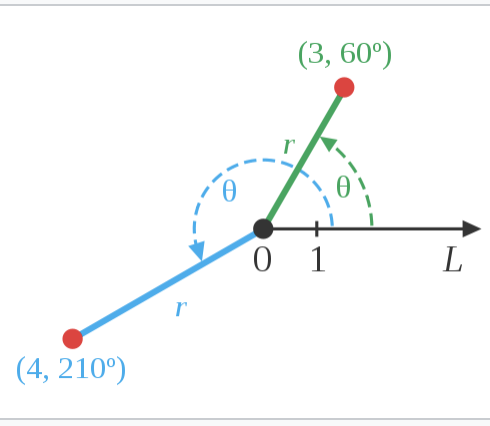
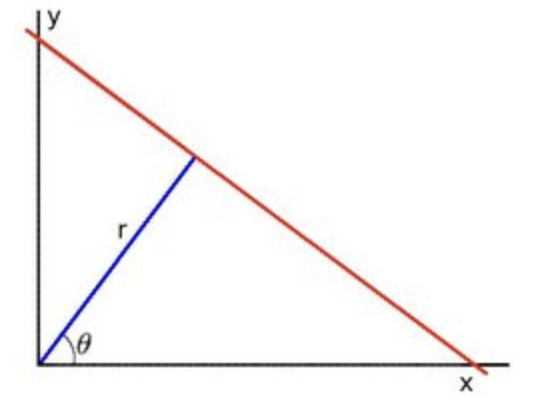
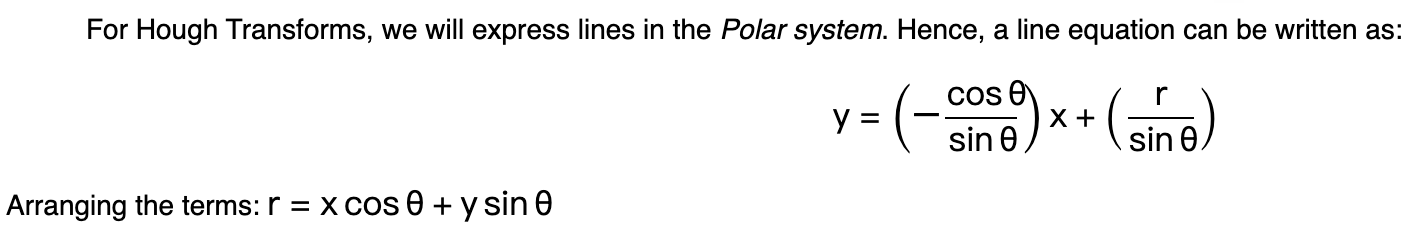

In [20]:
import cv2
import numpy as np

image = cv2.imread('images/soduku.jpg')

# Grayscale 和 Canny edge

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)
# Run HoughLines 1px 
# theta accuracy of np.pi / 180 = 1 degree
# line threshold 線路閾值 設置為240 - 線點數
lines = cv2.HoughLines(edges, 1, np.pi / 180, 225)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # (x0,y0) 值 a = np.cos(theta) b = np.sin(theta) x0 = a*rho y0 = b*rho 
    # # 1000 的目的是為了將線段延長
    # # 以 (x0,y0) 為原點，進行延長 x1 = int(x0+1000*(-b)) y1 = int(y0+1000*a) x2 = int(x0-1000*(-b)) y2 = int(y0-1000*a)

cv2.imshow('Hough Lines', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Probabilistic Hough Transform 
採用概率挑選機制，選取一些點出來計算，相當於down-sampling
lines = cv2.HoughLinesP(image, rho, theta, threshold[, lines[, minLineLength[, maxLineGap]]])

a. The Standard Hough Transform 

It consists in pretty much what we just explained in the previous section. It gives you as result a vector of couples (θ,rθ)
In OpenCV it is implemented with the function HoughLines()
b. The Probabilistic Hough Line Transform

A more efficient implementation of the Hough Line Transform. It gives as output the extremes of the detected lines (x0,y0,x1,y1)
In OpenCV it is implemented with the function HoughLinesP()


src：输入 8-bit 的灰度图像；  
rho：像素为单位的距离精度，double 类型的，推荐用 1.0；  
theta：以弧度为单位的角度精度，推荐用 numpy.pi/180；  
threshold：阈值；  
lines：输出的极坐标来表示直线；  
minLineLength：最短长度阈值，比这个长度短的线会被排除；  
maxLineGap：最大间隔，如果小于此值，这两条直线就被看成是一条直线。  

In [5]:
import cv2
import numpy as np

# Grayscale & Canny

image = cv2.imread('images/soduku.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)

# 使用相同 rho and theta 準確度 accuracies
# 規定了最低投票數（沿著線數）minimum vote (pts along line) - 為 100 
# 最小線長度 Min line length 為 5像素  5 pixels，最大間隙  max gap 為 10像素 10 pixels 


lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, 5, 40)
print (lines.shape)

for line in lines:
    x1,y1,x2,y2 = line[0]
    cv2.line(image, (x1, y1), (x2, y2),(0, 255, 0), 3)

cv2.imshow('Probabilistic Hough Lines', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

(10, 1, 4)


# Circle 圓檢測 - Detection - Hough Cirlces

**cv2.HoughCircles**(image, method, dp, MinDist, param1, param2, minRadius, MaxRadius)


- Method - cv2.HOUGH_GRADIENT & cv2.HOUGH_GRADIENT_ALT兩種可選
- dp：檢測圓心的累加器精度和圖像精度比的倒數，比如dp=1時累加器和輸入圖像有相同的解析度，dp=2時累加器是輸入圖像一半大的寬高;method=cv2. HOUGH_GRADIENT_ALT時推薦設置dp=1.5。
- minDist：檢測到圓心的間距，設置的越小可能檢測的圓形越多，設置的越大可能會錯過一些圓形的檢測。
- param1：特定方法參數，和method配合;當method=cv2. HOUGH_GRADIENT或method=cv2. HOUGH_GRADIENT_ALT時，該參數是canny檢測的高閾值，低閾值是該參數的一半;method=cv2. HOUGH_GRADIENT_ALT時，內部使用Scharr計算圖像梯度，這個值通常要設置得更大。
- param2：特定方法參數，和method配合;當method=cv2. OUGH_GRADIENT，它表示檢測階段圓心的累加器閾值，越小就會檢測到更多的圓，越大能通過檢測的圓就更加精確。 當method=cv2. HOUGH_GRADIENT_ALT時，該參數可以看做是圓的“完美性”度量，它越接近1演算法選擇的圓形形狀越好，一般可以設置在0.9。 如果想要更好地檢測小圓，可以設置在0.85、0.8甚至更小，通過限制搜索範圍[minRadius，maxRadius]可以避免出現許多假圓。
- minRadius：最小圓半徑。
- maxRadius：最大圓半徑，如果設置為<=0，使用最大圖像尺寸;如果<0時且method=cv2. HOUGH_GRADIENT用來查找圓心而忽略半徑的查找，method=cv2. HOUGH_GRADIENT_ALT不受影響，始終會去找半徑。
- circles：返回的圓形的點，是一個三維陣列
用HoughCircles（）方法找到的圓形，通常圓心的準確率比較高，半徑的準確率比較低，可以藉助minRadius和maxRadius 2個參數來限制半徑的範圍提高查找的精確度。

In [ ]:
import cv2
import numpy as np

image = cv2.imread('images/bottlecaps.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.medianBlur(gray, 5)


circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, 2, 50,minRadius=30,maxRadius=60)
#circles = cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,2, 50,
#                            param1=2,param2=50,minRadius=30,maxRadius=70)

circles = np.uint16(np.around(circles))

for i in circles[0]:
    # draw 畫出外圈 - outer circle
    cv2.circle(image,(i[0], i[1]), i[2], (255, 0, 0), 2)
    
    # draw 圓的 中心點 - center of the circle
    cv2.circle(image, (i[0], i[1]), 2, (0, 255, 0), 5)

cv2.imshow('detected circles', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Blob Detection

detector = cv2.SimpleBlobDetector_create()
keypoints = detector.detect(image)

A Blob is a group of connected pixels in an image that share some common property ( E.g, grayscale value ). In the image above, the dark connected regions are blobs, and blob detection aims to identify and mark these regions.

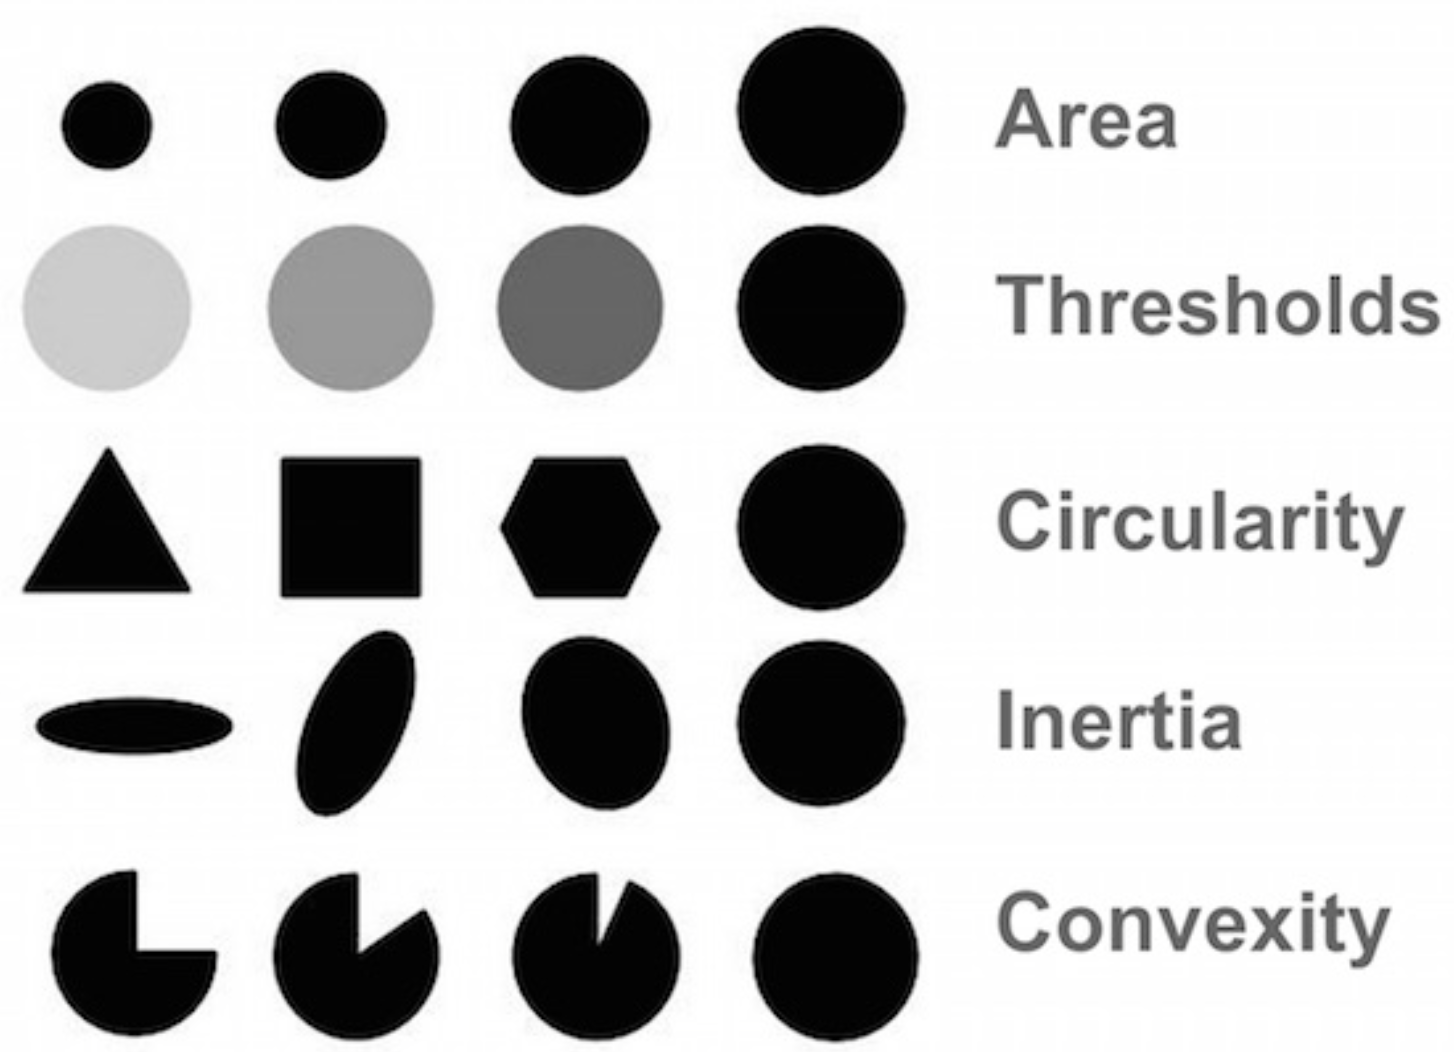

**cv2.drawKeypoints**(input image, keypoints, blank_output_array, color, flags)

flags:
- cv2.DRAW_MATCHES_FLAGS_DEFAULT:只畫特徵點座標，顯示在圖上就是一個個小圓點，每個小圓點的圓心座標即特徵點座標
- cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS：繪製特徵點時畫出一個個帶有方向的圓，同時顯示座標，size與方向，是最能顯示特徵的方式
- cv2.DRAW_MATCHES_FLAGS_DRAW_OVER_OUTIMG：不產生輸出的圖像，而是直接輸出圖像變量空間
- cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS：單點的特徵點不會畫出

In [3]:
import numpy as np;
import cv2

image = cv2.imread("images/Sunflowers.jpg")
 
# detector Use Default Parameters

# detector = cv2.SimpleBlobDetector()
detector = cv2.SimpleBlobDetector_create()



# Detect - blobs.

keypoints = detector.detect(image)
 
# Draw  Red Circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of
# circle 

blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,0,255),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS )
print(blobs) 
# keyPoints

cv2.imshow("Blobs", blobs)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

[[[247 159 118]
  [247 159 118]
  [246 158 117]
  ...
  [255 178 139]
  [254 177 138]
  [253 176 137]]

 [[253 168 128]
  [253 168 128]
  [252 167 127]
  ...
  [250 172 126]
  [250 172 126]
  [251 173 127]]

 [[255 175 134]
  [255 175 134]
  [255 175 134]
  ...
  [249 166 115]
  [249 166 115]
  [249 166 115]]

 ...

 [[  1  26  16]
  [  4  25  17]
  [  0  17  14]
  ...
  [  2  18   7]
  [  3  19   8]
  [  2  18   7]]

 [[  2  26  16]
  [  4  25  17]
  [  1  15  13]
  ...
  [  0  16   5]
  [  0  15   4]
  [  0  15   4]]

 [[  3  27  17]
  [  5  23  16]
  [  0  13  11]
  ...
  [  0  15   4]
  [  0  15   4]
  [  4  20   9]]]


In [ ]:
import cv2
import numpy as np



image = cv2.imread("images/blobs.jpg", 0)
cv2.imshow('Original Image',image)
cv2.waitKey(0)

# Intialize  detector default parameters

detector = cv2.SimpleBlobDetector_create()
 
# Detect blobs

keypoints = detector.detect(image)
 
# Draw blob as red circles

blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,0,255),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Total Number of Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550), cv2.FONT_HERSHEY_SIMPLEX, 1, (100, 0, 255), 2)

# Display 顯示圖像 image - 關鍵點 blob keypoints


cv2.imshow("Blobs using default parameters", blobs)
cv2.waitKey(0)


# 設置 過濾參數 - filtering parameters
# 初始化參數設置  parameter -  cv2.SimpleBlobDetector_create


params = cv2.SimpleBlobDetector_Params()

# Set Area filtering parameters
params.filterByArea = True
params.minArea = 100

# 設置區域過濾參數 - Circularity filtering parameters

params.filterByCircularity = True 
params.minCircularity = 0.9

# 設置區域過濾參數 - Convexity filtering parameters

params.filterByConvexity = False
params.minConvexity = 0.2
    
# 設置慣性濾波參數 - inertia filtering parameters

params.filterByInertia = True
params.minInertiaRatio = 0.01

# 參數創建檢測器 detector with the  參數 parameters
# detector = cv2.SimpleBlobDetector(params)

detector = cv2.SimpleBlobDetector_create(params)    
# detect blobs



keypoints = detector.detect(image)

# Drawblob as red circles

blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,255,0),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Number of Circular Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 100, 255), 2)

# display blobs
cv2.imshow("Filtering Circular Blobs Only", blobs)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

Finding Waldo

In [2]:
import cv2
import numpy as np

# Load 加載輸入圖像, 轉換為灰度- grayscale

image = cv2.imread('images/WaldoBeach.jpg')
cv2.imshow('Where is Waldo?', image)
cv2.waitKey(0)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Load 加載 waldo 圖像 - Template image

template = cv2.imread('images/waldo.jpg',0)

result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

#Create 創建 邊界框 - Bounding Box

top_left = max_loc
bottom_right = (top_left[0] + 50, top_left[1] + 50)
cv2.rectangle(image, top_left, bottom_right, (0,0,255), 5)

cv2.imshow('Where is Waldo?', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range(2):
    cv2.waitKey(1)

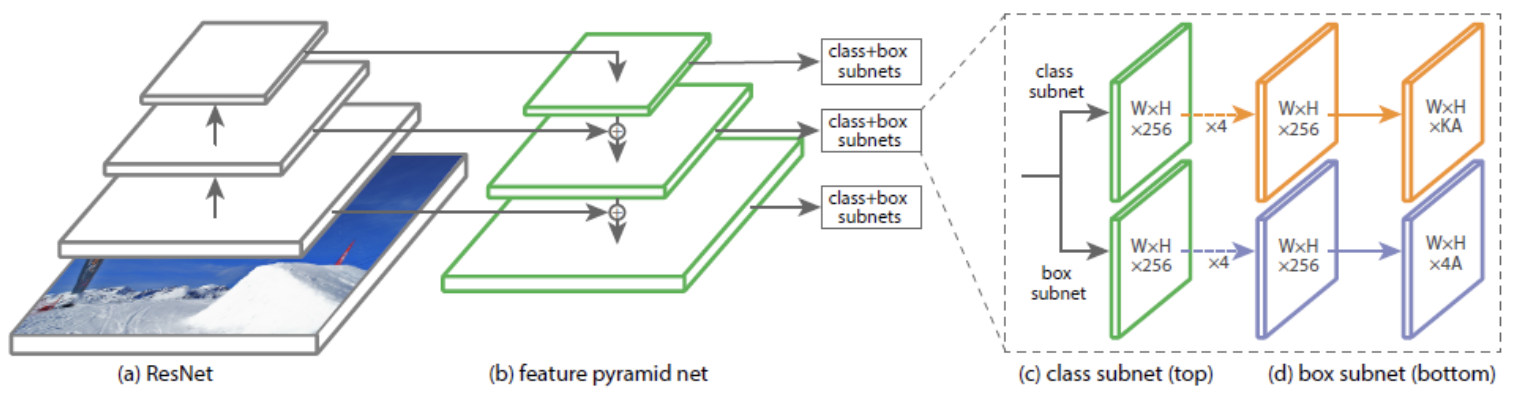
https://github.com/yhenon/pytorch-retinanet/tree/master/retinanet
https://zhuanlan.zhihu.com/p/143877125